Knowing that x-ray images contain patterns specific to certain diseases, we can try to prelearn our model with those patterns in the appropriate convolution kernels.

In [1]:
# Use this cell, whenever a change was made to the helper functions
# and the library needs to be reloaded in order to take effect
import preparations as prep # dataset loading and definitions
import helper as hlp # helper functions for plotting and image processing
import prediction # prediction functions
import importlib
importlib.reload(hlp)
importlib.reload(prep)
importlib.reload(prediction)

<module 'prediction' from '/content/prediction.py'>

In [2]:
# Libraries
import os
import pandas as pd
import numpy as np

# Imports for model building
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Conv2D

# Callbacks
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Reporting t
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from imblearn.metrics import classification_report_imbalanced

# Imports for visualizations
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
# List available GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("✅ TensorFlow is using a GPU:")
    for gpu in gpus:
        print("  -", gpu)
else:
    print("❌ No GPU detected. TensorFlow is using the CPU.")

✅ TensorFlow is using a GPU:
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [5]:
# Load the original dataset, if not done yet
prep.download_and_move_dataset()

Dataset already exists.


In [6]:
# Read in the images
train_ds, val_ds, class_names = hlp.read_only_xray_images(input_shape=(256,256))

Created empty directory: /tmp_744634375
Made directory: /tmp_744634375/Lung_Opacity/
Moved /COVID-19_Radiography_Dataset/Lung_Opacity/masks to /tmp_744634375/Lung_Opacity/masks
Made directory: /tmp_744634375/COVID/
Moved /COVID-19_Radiography_Dataset/COVID/masks to /tmp_744634375/COVID/masks
Made directory: /tmp_744634375/Viral Pneumonia/
Moved /COVID-19_Radiography_Dataset/Viral Pneumonia/masks to /tmp_744634375/Viral Pneumonia/masks
Made directory: /tmp_744634375/Normal/
Moved /COVID-19_Radiography_Dataset/Normal/masks to /tmp_744634375/Normal/masks
Found 21165 files belonging to 4 classes.
Using 16932 files for training.
Using 4233 files for validation.
Found classes: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
Train dataset batch: (32, 256, 256, 3) (32,)
Labels [1 1 2 2 2 2 1 2 2 2 0 2 1 2 2 2 0 2 0 2 0 1 1 1 2 1 2 1 2 2 0 2]
Validation dataset batch: (32, 256, 256, 3) (32,)
Labels [1 2 1 1 0 2 2 3 1 2 0 2 2 2 1 2 1 2 3 2 2 2 0 2 2 0 1 1 3 2 0 1]
Moved /tmp_744634375/Lun

In [7]:
# Convert grayscale (256,256,3) -> (256,256,1) in order to make it simpler for our model
# Function to ensure images are in (256,256,1) format
def to_grayscale(image, label):
    image = tf.image.rgb_to_grayscale(image) if image.shape[-1] == 3 else image  # Convert if needed
    return image, label

train_ds = train_ds.map(to_grayscale)
val_ds = val_ds.map(to_grayscale)

In [8]:
# Number of batches in the training dataset
print("Number of batch in train_ds:", train_ds.cardinality().numpy())

# Number of batches in the validation dataset
print("Number of batch in val_ds:", val_ds.cardinality().numpy())

# Let's check compatible input format for our model
for images, labels in train_ds.take(1):
    print('Batch shape:', images.shape, labels.shape)
    # Show some sample image shapes and according labels (should be shuffled!)
    for image, label in zip(images.numpy(),labels.numpy()):
        print(image.shape, label)

Number of batch in train_ds: 530
Number of batch in val_ds: 133
Batch shape: (32, 256, 256, 1) (32,)
(256, 256, 1) 1
(256, 256, 1) 2
(256, 256, 1) 2
(256, 256, 1) 3
(256, 256, 1) 1
(256, 256, 1) 2
(256, 256, 1) 0
(256, 256, 1) 1
(256, 256, 1) 2
(256, 256, 1) 0
(256, 256, 1) 2
(256, 256, 1) 2
(256, 256, 1) 1
(256, 256, 1) 2
(256, 256, 1) 1
(256, 256, 1) 3
(256, 256, 1) 2
(256, 256, 1) 2
(256, 256, 1) 2
(256, 256, 1) 2
(256, 256, 1) 1
(256, 256, 1) 0
(256, 256, 1) 0
(256, 256, 1) 1
(256, 256, 1) 1
(256, 256, 1) 0
(256, 256, 1) 1
(256, 256, 1) 1
(256, 256, 1) 1
(256, 256, 1) 1
(256, 256, 1) 0
(256, 256, 1) 0


In [9]:
# We have imbalanced data, hence let's calculate class_weights to give it the model
from collections import Counter

# Count occurrences of each class
class_counts = Counter()
total_count = 0
for images, labels in train_ds:
    for label in labels.numpy():  # Convert tensor to numpy
        class_counts[label] += 1
        total_count += 1

# Convert label indices to class names
class_counts_named = {class_names[idx]: count for idx, count in class_counts.items()}
print("Class Counts:", class_counts_named)

class_weights_dict = { class_label: total_count / (len(class_counts) * class_counts[class_label])
                 for class_label, class_count in class_counts.items() }
print('Class Weights:', class_weights_dict)

Class Counts: {'Viral Pneumonia': 1048, 'Lung_Opacity': 4847, 'Normal': 8134, 'COVID': 2903}
Class Weights: {np.int32(3): 4.03912213740458, np.int32(1): 0.8733237053847741, np.int32(2): 0.5204081632653061, np.int32(0): 1.4581467447468137}


In [10]:
# Make sure, the models folder exists
if not os.path.exists(os.path.join('..', 'models')):
    os.makedirs(os.path.join('..', 'models'))

In [11]:
# Applied Callbacks
early_stopping = EarlyStopping(
                                patience=5, # Wait for 5 epochs before applying
                                min_delta=0.01, # If the loss function doesn't change by 1% after 5 epochs, either up or down, we stop
                                verbose=1, # Display the epoch at which training stops
                                mode='min',
                                monitor='val_loss')

# A learning rate reduction callback to reduce the learning rate when the validation loss stagnates
reduce_learning_rate = ReduceLROnPlateau(
                                    monitor="val_loss",
                                    patience=5, # If val_loss stagnates for 5 consecutive epochs based on the min_delta value
                                    min_delta=0.01,
                                    factor=0.1,  # Reduce the learning rate by a factor of 0.1
                                    cooldown=3,  # Wait 3 epochs before retrying
                                    verbose=1)

Strategy for the First Convolutional Layer

Use medically relevant kernels:
* Sobel filters → Detect lung boundaries.
* Laplacian filters → Highlight nodules and opacities.
* Gabor filters → Capture texture changes (useful for pneumonia, fibrosis).
* Gaussian filters → Enhance image contrast.
- Randomly initialize remaining filters (if we don’t have 64 predefined kernels).
- Apply small noise and transformations to all filters to ensure diversity.

In [12]:
# Let's create our specialized medical convolution layer
import cv2

# Function to create a Gabor filter
def gabor_kernel(ksize=3, sigma=1.0, theta=0, lambd=10.0, gamma=0.5, psi=0):
    return cv2.getGaborKernel((ksize, ksize), sigma, theta, lambd, gamma, psi, ktype=cv2.CV_32F)

# Define known kernels (3x3)
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)  # Edge detection
sobel_y = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]], dtype=np.float32)  # Vertical edges
laplacian = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]], dtype=np.float32)  # Enhancing details
gaussian = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]], dtype=np.float32) / 16  # Smoothing
gabor = gabor_kernel()  # Extracts textures

# Store the known filters in a list
known_filters = [sobel_x, sobel_y, laplacian, gaussian, gabor]

# Number of filters needed
total_filters = 64
known_filter_count = len(known_filters)
remaining_filters = total_filters - known_filter_count

# Initialize filter tensor (3,3,1,64)
filters = np.zeros((3, 3, 1, total_filters), dtype=np.float32)

# Assign known filters
for i, kernel in enumerate(known_filters):
    filters[:, :, 0, i] = kernel  # Each kernel occupies one filter slot

# Assign random filters for the remaining slots
for i in range(known_filter_count, total_filters):
    random_kernel = np.random.randn(3, 3) * 0.1  # Small random values
    random_kernel +=  known_filters[np.random.choice(known_filter_count)] # Base it on a known filter with noise
    filters[:, :, 0, i] = random_kernel

# Define the first convolutional layer with these filters
med_conv_layer = tf.keras.layers.Conv2D(
    filters=total_filters, kernel_size=(3,3), activation='relu',
    kernel_initializer=tf.keras.initializers.Constant(filters),
    padding="same"
)

In [13]:
# Build a model with it
# Define the full CNN model
model = tf.keras.Sequential([
    Input(shape=(256, 256, 1)),  # X-ray grayscale input
    med_conv_layer,  # Predefined first convolution layer with 64 neurons
    MaxPooling2D((2,2)),  # Reduce feature map size
    Conv2D(128, (3,3), activation='relu'),  # Deeper learned features
    MaxPooling2D((2,2)),
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(512, (3,3), activation='relu'),
    GlobalAveragePooling2D(),
    Dense(1024, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(len(class_names), activation='softmax')
])

In [14]:
# Compile with first idea of appropriate parameters
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Print how it looks like
model.summary()

# Convert summary to DataFrame and display it (for copy and paste purposes)
df_summary = hlp.model_summary_to_df(model)
display(df_summary)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 256, 256, 64)        │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 128, 128, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 126, 126, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 63, 63, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 61, 61, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1024)                │         525,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │         131,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,206,852 (8.42 MB)

 Trainable params: 2,206,852 (8.42 MB)

 Non-trainable params: 0 (0.00 B)

,Layer Name (type),Output Shape,Param Count
0,conv2d (Conv2D),"(None, 256, 256, 64)",640
1,max_pooling2d (MaxPooling2D),"(None, 128, 128, 64)",0
2,conv2d_1 (Conv2D),"(None, 126, 126, 128)","73,856"
3,max_pooling2d_1 (MaxPooling2D),"(None, 63, 63, 128)",0
4,conv2d_2 (Conv2D),"(None, 61, 61, 256)","295,168"
5,max_pooling2d_2 (MaxPooling2D),"(None, 30, 30, 256)",0
6,conv2d_3 (Conv2D),"(None, 28, 28, 512)","1,180,160"
7,global_average_pooling2d,"(None, 512)",0
8,(GlobalAveragePooling2D),,
9,dense (Dense),"(None, 1024)","525,312"


In [15]:
# Train it with the entire dataset (takes very long!) without early stopping
history_model = model.fit(train_ds,
                          epochs=25,
                          validation_data=val_ds,
                          class_weight=class_weights_dict,
                          callbacks=[reduce_learning_rate])

Epoch 1/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.4060 - loss: 9.9232 - val_accuracy: 0.6029 - val_loss: 0.8937 - learning_rate: 0.0010
Epoch 2/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.6178 - loss: 0.7605 - val_accuracy: 0.6867 - val_loss: 0.7804 - learning_rate: 0.0010
Epoch 3/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.6652 - loss: 0.6647 - val_accuracy: 0.7340 - val_loss: 0.6416 - learning_rate: 0.0010
Epoch 4/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.7025 - loss: 0.5851 - val_accuracy: 0.7616 - val_loss: 0.5962 - learning_rate: 0.0010
Epoch 5/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.7382 - loss: 0.5102 - val_accuracy: 0.7765 - val_loss: 0.5877 - learning_rate: 0.0010
Epoch 6/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.7682 - loss: 0.4508 - val_accuracy: 0.7756 - val_loss: 0.6109 - learning_rate: 0.0010
Epoch 7/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.7888 - l

In [16]:
model_name = os.path.join('..', 'models', '4_25ep_medparam_4xconv2d_dense128.keras')
model.save(model_name)

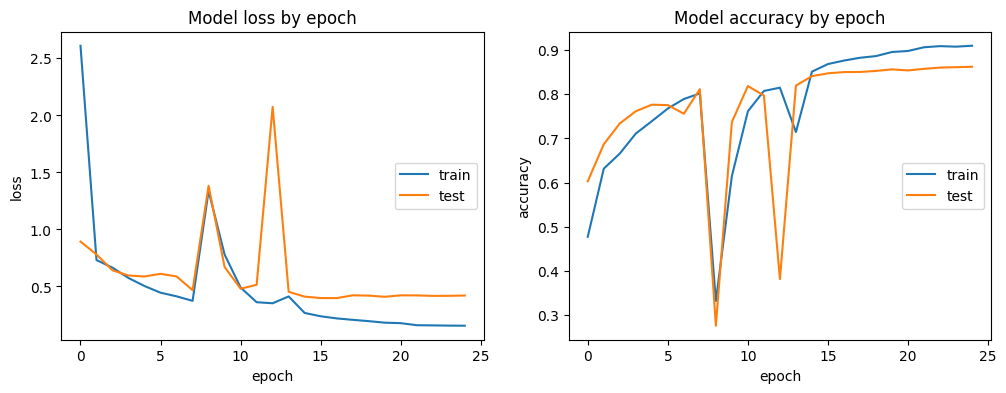

In [17]:
hlp.plot_learning_curve(history_model)

In [19]:
#y_true, y_pred = get_predictions_and_labels(vgg16, val_ds.take(8)) # for a quick result
y_true, y_pred = hlp.get_predictions_and_labels(model, val_ds)

,pre,rec,spe,f1,geo,iba,sup
COVID,0.934337,0.957924,0.986364,0.945983,0.972040,0.942175,713.000000
Lung_Opacity,0.798748,0.766524,0.926662,0.782304,0.842798,0.698934,1165.000000
Normal,0.864839,0.873664,0.870805,0.869229,0.872233,0.761008,2058.000000
Viral Pneumonia,0.908197,0.932660,0.992886,0.920266,0.962302,0.920448,297.000000
avg_pre,0.861398,0.861398,0.861398,0.861398,0.861398,0.861398,0.861398
avg_rec,0.862509,0.862509,0.862509,0.862509,0.862509,0.862509,0.862509
avg_spe,0.914208,0.914208,0.914208,0.914208,0.914208,0.914208,0.914208
avg_f1,0.861815,0.861815,0.861815,0.861815,0.861815,0.861815,0.861815
avg_geo,0.887263,0.887263,0.887263,0.887263,0.887263,0.887263,0.887263
avg_iba,0.785626,0.785626,0.785626,0.785626,0.785626,0.785626,0.785626


Predicted,COVID,Lung_Opacity,Normal,Viral Pneumonia
COVID,683,11,16,3
Lung_Opacity,21,893,251,0
Normal,23,212,1798,25
Viral Pneumonia,4,2,14,277


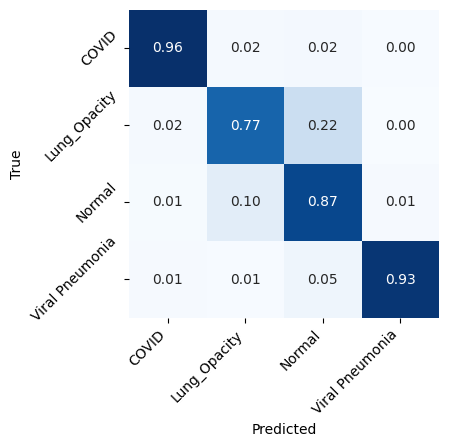

{'crosstab': Predicted        COVID  Lung_Opacity  Normal  Viral Pneumonia
 COVID              683            11      16                3
 Lung_Opacity        21           893     251                0
 Normal              23           212    1798               25
 Viral Pneumonia      4             2      14              277,
 'classification_report':                          pre          rec          spe           f1  \
 COVID               0.934337     0.957924     0.986364     0.945983   
 Lung_Opacity        0.798748     0.766524     0.926662     0.782304   
 Normal              0.864839     0.873664     0.870805     0.869229   
 Viral Pneumonia     0.908197     0.932660     0.992886     0.920266   
 avg_pre             0.861398     0.861398     0.861398     0.861398   
 avg_rec             0.862509     0.862509     0.862509     0.862509   
 avg_spe             0.914208     0.914208     0.914208     0.914208   
 avg_f1              0.861815     0.861815     0.861815     0.861815   

In [20]:
hlp.report_model_performance(y_true, y_pred, class_names)
# not too bad

In [21]:
# Run another 25 epochs and train even further since we still converge,
# this time with reduced learning rate
history_model_2 = model.fit(train_ds.shuffle(1000),
                          epochs=25,
                          validation_data=val_ds,
                          class_weight=class_weights_dict,
                          callbacks=[reduce_learning_rate])

Epoch 1/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.9062 - loss: 0.1580 - val_accuracy: 0.8587 - val_loss: 0.4336 - learning_rate: 1.0000e-05
Epoch 2/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.9104 - loss: 0.1509 - val_accuracy: 0.8618 - val_loss: 0.4270 - learning_rate: 1.0000e-05
Epoch 3/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.9133 - loss: 0.1485 - val_accuracy: 0.8646 - val_loss: 0.4230 - learning_rate: 1.0000e-05
Epoch 4/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.9173 - loss: 0.1453 - val_accuracy: 0.8642 - val_loss: 0.4244 - learning_rate: 1.0000e-05
Epoch 5/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.9188 - loss: 0.1449 - val_accuracy: 0.8592 - val_loss: 0.4540 - learning_rate: 1.0000e-05
Epoch 6/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.9173 - loss: 0.1458 - val_accuracy: 0.8632 - val_loss: 0.4315 - learning_rate: 1.0000e-05
Epoch 7/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/ste

##### Evaluation

In [22]:
# Save the model for potential later use
model_name = os.path.join('..', 'models', '4_50ep_medparam_4xconv2d_dense128.keras')
model.save(model_name)

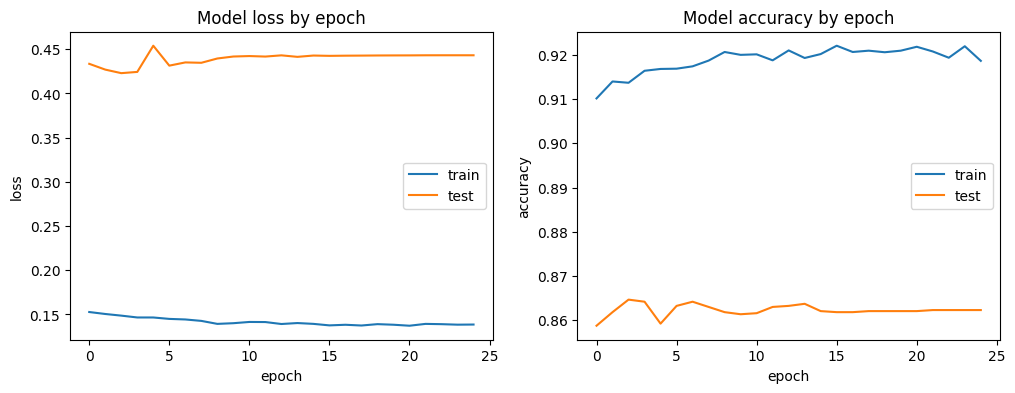

In [23]:
hlp.plot_learning_curve(history_model_2)

In [24]:
# and load it again (to check proper saving)
from tensorflow import keras
model = keras.models.load_model(model_name)

In [25]:
#y_true, y_pred = get_predictions_and_labels(vgg16, val_ds.take(8)) # for a quick result
y_true, y_pred = hlp.get_predictions_and_labels(model, val_ds)

,pre,rec,spe,f1,geo,iba,sup
COVID,0.934516,0.960729,0.986364,0.947441,0.973462,0.945199,713.000000
Lung_Opacity,0.793286,0.770815,0.923729,0.781889,0.843815,0.701137,1165.000000
Normal,0.866828,0.869776,0.873563,0.868300,0.871668,0.759517,2058.000000
Viral Pneumonia,0.914191,0.932660,0.993394,0.923333,0.962548,0.920872,297.000000
avg_pre,0.861312,0.861312,0.861312,0.861312,0.861312,0.861312,0.861312
avg_rec,0.862273,0.862273,0.862273,0.862273,0.862273,0.862273,0.862273
avg_spe,0.914777,0.914777,0.914777,0.914777,0.914777,0.914777,0.914777
avg_f1,0.861710,0.861710,0.861710,0.861710,0.861710,0.861710,0.861710
avg_geo,0.887525,0.887525,0.887525,0.887525,0.887525,0.887525,0.887525
avg_iba,0.786047,0.786047,0.786047,0.786047,0.786047,0.786047,0.786047


Predicted,COVID,Lung_Opacity,Normal,Viral Pneumonia
COVID,685,9,15,4
Lung_Opacity,21,898,246,0
Normal,23,223,1790,22
Viral Pneumonia,4,2,14,277


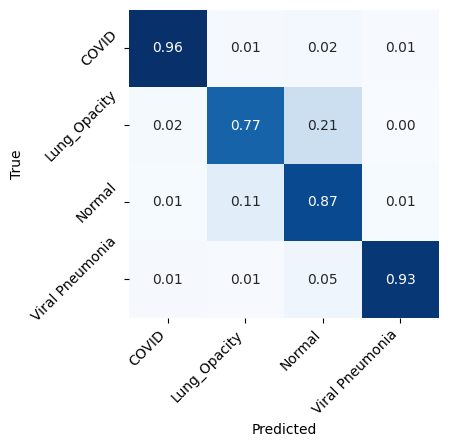

{'crosstab': Predicted        COVID  Lung_Opacity  Normal  Viral Pneumonia
 COVID              685             9      15                4
 Lung_Opacity        21           898     246                0
 Normal              23           223    1790               22
 Viral Pneumonia      4             2      14              277,
 'classification_report':                          pre          rec          spe           f1  \
 COVID               0.934516     0.960729     0.986364     0.947441   
 Lung_Opacity        0.793286     0.770815     0.923729     0.781889   
 Normal              0.866828     0.869776     0.873563     0.868300   
 Viral Pneumonia     0.914191     0.932660     0.993394     0.923333   
 avg_pre             0.861312     0.861312     0.861312     0.861312   
 avg_rec             0.862273     0.862273     0.862273     0.862273   
 avg_spe             0.914777     0.914777     0.914777     0.914777   
 avg_f1              0.861710     0.861710     0.861710     0.861710   

In [26]:
hlp.report_model_performance(y_true, y_pred, class_names)

# Conclusion: Our model predicts the 4 classes ...

##### Try some sample images

In [ ]:
models = {'4-fromscratch': model}

In [ ]:
model.input_shape[-1]

1

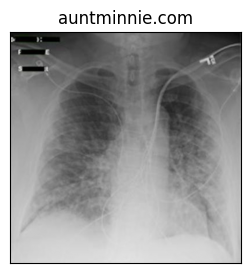

Resizing for model 4-fromscratch to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 709ms/step


,Model_Prediction,COVID,Lung_Opacity,Normal,Viral Pneumonia
4-fromscratch,COVID,0.998,0.0,0.002,0.0


In [ ]:
file_url = 'https://img.auntminnie.com/files/base/smg/all/image/2022/02/am.2022_02_02_00_09_3090_2022_02_03_CXR_covid_19_20220202005447.png?auto=format%2Ccompress&q=70&w=880'
helper.show_predict_image('auntminnie.com', hlp.load_image_from_url(file_url), models)

# Nice, perfectly predicted

(612, 1536, 3)


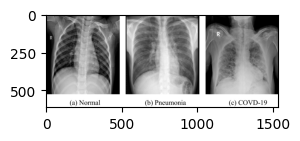

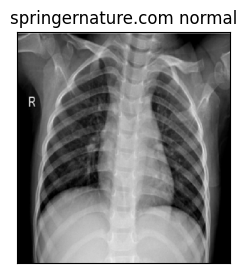

Resizing for model 4-fromscratch to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


,Model_Prediction,COVID,Lung_Opacity,Normal,Viral Pneumonia
4-fromscratch,Normal,0.0,0.0,1.0,0.0


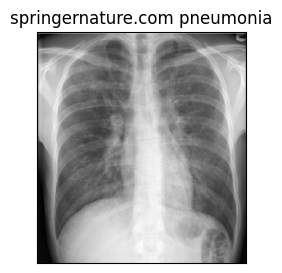

Resizing for model 4-fromscratch to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


,Model_Prediction,COVID,Lung_Opacity,Normal,Viral Pneumonia
4-fromscratch,COVID,0.635,0.002,0.08,0.284


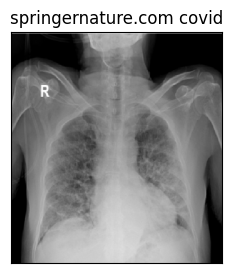

Resizing for model 4-fromscratch to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


,Model_Prediction,COVID,Lung_Opacity,Normal,Viral Pneumonia
4-fromscratch,COVID,1.0,0.0,0.0,0.0


In [ ]:
norm_pneu_covid_url='https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs41598-022-27266-9/MediaObjects/41598_2022_27266_Fig1_HTML.png'

img_norm_pneu_covid = hlp.load_image_from_url(norm_pneu_covid_url)
print(img_norm_pneu_covid.shape)
plt.figure(figsize=(3,3))
plt.imshow(img_norm_pneu_covid/255)
plt.show()

img_normal = img_norm_pneu_covid[:520,:480,:]
img_pneumonia = img_norm_pneu_covid[:520,530:1000,:]
img_covid = img_norm_pneu_covid[:520:,1060:,:]

helper.show_predict_image('springernature.com normal', img_normal, models)
helper.show_predict_image('springernature.com pneumonia', img_pneumonia, models)
helper.show_predict_image('springernature.com covid', img_covid, models)

# also not bad, only pneumonia was more detected as COVID